# **(Feature Engineering)**

## Objectives

* Resize all images if necessary
* Convert all images to the same colour format if necessary
  

## Inputs

* inputs/skin_cancer_dataset/test
* inputs/skin_cancer_dataset/train
* inputs/skin_cancer_dataset/Validation

## Outputs

* image_sizes.pkl
## Additional Comments

* No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory
  
We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()


In [3]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-cancer-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-cancer-detector'

---

# Data Directories

## Input Directories

Set train, validation, and test paths so machine knows where the data is

In [6]:
my_data_dir = 'inputs/skin_cancer_dataset'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so machine knows where to place the outputs

In [7]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)


Old version is already available create a new version.


## Set Label Names

In [8]:
labels = os.listdir(train_path)
print('Label for the images are', labels)

Label for the images are ['malignant', 'benign']


## Import libraries to work with

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set_style("white")
from matplotlib.image import imread
import pickle

---

## Image Shape

See the average image size in the train set

Average image size: 224.00 x 224.00 pixels (width x height)


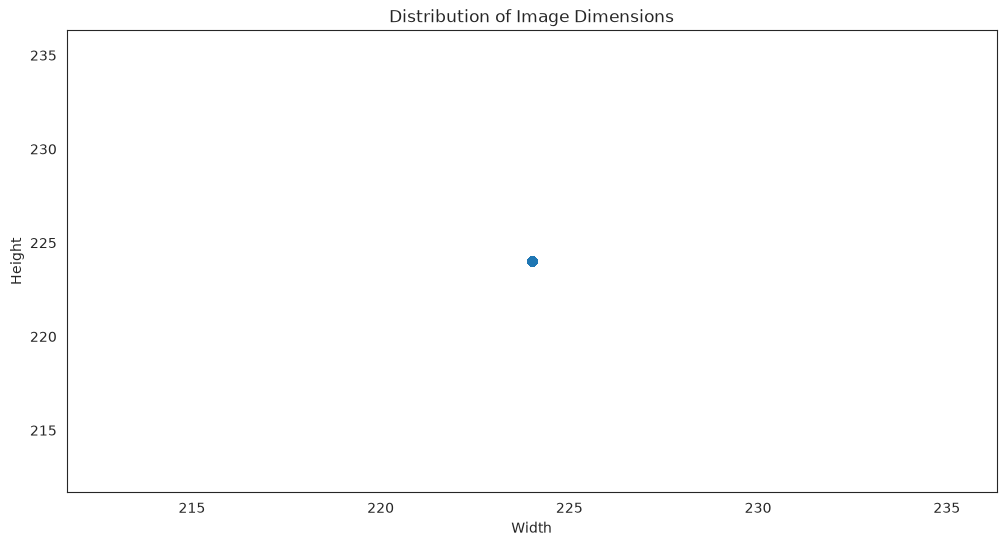

In [10]:
dim1 = []
dim2 = []

for label in labels:
    for image_filename in os.listdir(train_path + '/' + label):
        img = imread(train_path + '/' + label + '/' + image_filename)
        d1, d2, _ = img.shape
        dim1.append(d1)
        dim2.append(d2)

print(f'Average image size: {np.mean(dim2):.2f} x {np.mean(dim1):.2f} pixels (width x height)')
    
sns.set_style('white')
plt.figure(figsize=(12,6))
plt.title('Distribution of Image Dimensions')
plt.xlabel('Width')
plt.ylabel('Height')
plt.scatter(dim1, dim2)

In [11]:
image_sizes = set()

for label in labels:
    for image_filename in os.listdir(train_path + '/' + label):
        image = imread(train_path + '/' + label + '/' + image_filename)
        image_sizes.add(image.shape[:2])

print(f'Number of unique image sizes: {len(image_sizes)}')
print(f'Image sizes found (height, width): {sorted(image_sizes)}')

if len(image_sizes) == 1:
    print('All training images have the exact same size.')
else:
    print('Training images do not all have the same size.')

Number of unique image sizes: 1
Image sizes found (height, width): [(224, 224)]
All training images have the exact same size.


As seen above, all images have the same size(224px x 224px). Now there is no need to change the dimensions of the images. Lastly, we can save the plot as a .pkl file

In [12]:
joblib.dump(value=image_sizes, filename=f"{file_path}/image_sizes.pkl")

['outputs/v1/image_sizes.pkl']

---

## Colour Format

Here, we will check the colour format and see if ti needs any changing

In [13]:
from pathlib import Path
from PIL import Image


def convert_images_to_rgb(data_dir):
    supported_extensions = {'.jpg', '.jpeg', '.png'}
    converted_files = []

    for file_path in Path(data_dir).rglob('*'):
        if not file_path.is_file() or file_path.suffix.lower() not in supported_extensions:
            continue

        with Image.open(file_path) as image:
            if image.mode != 'RGB':
                image_format = image.format
                rgb_image = image.convert('RGB')
                rgb_image.save(file_path, format=image_format)
                converted_files.append(str(file_path))

    return converted_files


converted_files = convert_images_to_rgb('inputs/skin_cancer_dataset')
print(f'Converted {len(converted_files)} images to RGB.')

Converted 0 images to RGB.


Here we can see that all images were already in RGB format, so there is no need to change this.

---